In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib_venn import venn2

import gseapy as gp

plt.style.use("default")
sns.set_theme(style="whitegrid")

In [11]:
deg1 = pd.read_csv(
    "Results/Dataset1/GSE122063_DEGs.csv",
    index_col=0
)

sig1 = pd.read_csv(
    "Results/Dataset1/GSE122063_Significant_DEGs.csv",
    index_col=0
)

deg2 = pd.read_csv(
    "Results/Dataset2/GSE33000_DEGs.csv",
    index_col=0
)

sig2 = pd.read_csv(
    "Results/Dataset2/GSE33000_Significant_DEGs.csv",
    index_col=0
)

print(sig1.shape)
print(sig2.shape)

(914, 6)
(320, 3)


In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib_venn import venn2

import gseapy as gp

In [7]:
deg1 = pd.read_csv(
    "Results/Dataset1/GSE122063_DEGs.csv",
    index_col=0
)

sig1 = pd.read_csv(
    "Results/Dataset1/GSE122063_Significant_DEGs.csv",
    index_col=0
)

deg2 = pd.read_csv(
    "Results/Dataset2/GSE33000_DEGs.csv",
    index_col=0
)

sig2 = pd.read_csv(
    "Results/Dataset2/GSE33000_Significant_DEGs.csv",
    index_col=0
)

print(sig1.shape)
print(sig2.shape)

(914, 6)
(320, 3)


In [12]:
sig1.index = sig1.index.astype(str).str.upper().str.strip()
sig2.index = sig2.index.astype(str).str.upper().str.strip()

deg1.index = deg1.index.astype(str).str.upper().str.strip()
deg2.index = deg2.index.astype(str).str.upper().str.strip()

In [13]:
shared = sig1.index.intersection(sig2.index)

print(f"Shared DEGs: {len(shared)}")

shared[:20]

Shared DEGs: 0


Index([], dtype='object')

In [14]:
print(sig1.index[:20].tolist())
print(sig2.index[:20].tolist())

['3299', '1004', '4583', '531', '242', '9846', '10381', '8380', '7753', '14170', '1587', '15016', '8732', '8167', '14805', '5304', '9962', '5331', '1779', '17218']
['NRN1', 'NEUROD6', 'PPEF1', 'SVOP', 'BDNF', 'VGF', 'HSPB3', 'FRMPD2', 'ITPKB', 'CA10', 'CAMK4', 'NFKBIA', 'CRH', 'LOC401097', 'MAL2', 'CBLN4', 'BEX5', 'SCG3', 'VWC2', 'PAK1']


In [15]:
print(sig1.index.name)
print(sig2.index.name)

None
GeneSymbol


In [16]:
print(sig1.head())
print(sig2.head())

       Gene     logFC       P.Value          t     adj.P.Val  Significant
3299  CIRBP -1.336824  1.000729e-19 -11.427388  1.235591e-15         True
1004   SPP1  1.923814  1.155478e-19  11.398260  1.235591e-15         True
4583  SPON2 -1.661841  6.840164e-19 -11.038920  4.388649e-15         True
531   CRYAB  1.053593  1.389147e-18  10.896181  6.366263e-15         True
242   HSPB1  1.155133  1.222200e-18  10.921962  6.366263e-15         True
               logFC       P.Value     adj.P.Val
GeneSymbol                                      
NRN1       -0.340629  1.877512e-82  3.128686e-78
NEUROD6    -0.505063  4.354395e-82  3.628082e-78
PPEF1      -0.636033  2.678691e-79  1.487924e-75
SVOP       -0.384524  9.946951e-78  4.143900e-74
BDNF       -0.450985  2.344805e-74  3.552166e-71


In [17]:
deg1 = pd.read_csv("Results/Dataset1/GSE122063_DEGs.csv")
deg1.head()

,Unnamed: 0,Gene,logFC,P.Value,t,adj.P.Val,Significant
0,6315,TRAPPC2L,-0.899630,3.460639e-20,-11.642866,1.110173e-15,False
1,3299,CIRBP,-1.336824,1.000729e-19,-11.427388,1.235591e-15,True
2,1004,SPP1,1.923814,1.155478e-19,11.398260,1.235591e-15,True
3,4838,IDS,-0.837507,1.540799e-19,-11.339996,1.235721e-15,False
4,4583,SPON2,-1.661841,6.840164e-19,-11.038920,4.388649e-15,True


In [18]:
# Use gene symbols as the index
deg1 = deg1.set_index("Gene")
sig1 = sig1.set_index("Gene")

# Remove duplicate genes if any
deg1 = deg1[~deg1.index.duplicated(keep="first")]
sig1 = sig1[~sig1.index.duplicated(keep="first")]

In [19]:
deg1.index = deg1.index.astype(str).str.upper().str.strip()
sig1.index = sig1.index.astype(str).str.upper().str.strip()

deg2.index = deg2.index.astype(str).str.upper().str.strip()
sig2.index = sig2.index.astype(str).str.upper().str.strip()

In [20]:
shared = sig1.index.intersection(sig2.index)

print("Shared DEGs:", len(shared))

shared[:20]

Shared DEGs: 113


Index(['CIRBP', 'RBM3', 'C4A', 'CARTPT', 'FCGBP', 'C4B', 'FRMPD2', 'GEM',
       'VGF', 'SERPINA3', 'CRH', 'MAFF', 'CD163', 'NUPR1', 'VSIG4', 'ITPKB',
       'C1QC', 'TNFRSF10B', 'CD44', 'HSPA1A'],
      dtype='object')

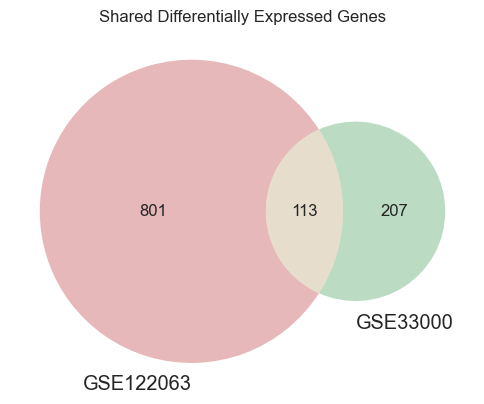

In [26]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt
import os

os.makedirs("Figures/Integrated", exist_ok=True)

plt.figure(figsize=(6,6))

venn2(
    [
        set(sig1.index),
        set(sig2.index)
    ],
    set_labels=("GSE122063", "GSE33000")
)

plt.title("Shared Differentially Expressed Genes")

plt.savefig(
    "Results/Integrated/Figure4_Venn_Shared_DEGs.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
shared_deg = pd.DataFrame(index=shared)

shared_deg["logFC_GSE122063"] = deg1.loc[shared, "logFC"]
shared_deg["FDR_GSE122063"] = deg1.loc[shared, "adj.P.Val"]

shared_deg["logFC_GSE33000"] = deg2.loc[shared, "logFC"]
shared_deg["FDR_GSE33000"] = deg2.loc[shared, "adj.P.Val"]

shared_deg = shared_deg.sort_values(
    "FDR_GSE122063"
)

shared_deg.head()

,logFC_GSE122063,FDR_GSE122063,logFC_GSE33000,FDR_GSE33000
CIRBP,-1.336824,1.235591e-15,-0.311016,2.185965e-54
RBM3,-1.615450,7.108740e-15,-0.399825,2.281911e-48
C4A,1.628674,2.073628e-13,0.561449,4.109874e-58
CARTPT,-2.828693,8.495509e-12,-0.418675,6.670023e-34
FCGBP,2.161771,2.372540e-11,0.528355,7.599413e-44


In [24]:
shared_deg.to_csv(
    "Results/Integrated/Shared_DEGs.csv"
)

In [27]:
shared_genes = shared_deg.index.tolist()

print(f"Number of shared genes: {len(shared_genes)}")
shared_genes[:10]

Number of shared genes: 113


['CIRBP',
 'RBM3',
 'C4A',
 'CARTPT',
 'FCGBP',
 'C4B',
 'FRMPD2',
 'GEM',
 'VGF',
 'SERPINA3']

In [28]:
go = gp.enrichr(
    gene_list=shared_genes,
    gene_sets="GO_Biological_Process_2023",
    organism="human",
    outdir=None
)

go_results = go.results.copy()

go_results = go_results.sort_values(
    "Adjusted P-value"
)

go_results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2023,Regulation Of Epinephrine Secretion (GO:0014060),3/5,0.000002,0.001551,0,0,271.159091,3595.749088,CRH;CARTPT;VIP
1,GO_Biological_Process_2023,Chemical Synaptic Transmission (GO:0007268),10/273,0.000003,0.001551,0,0,7.244269,91.137347,SNAP25;GABRA1;SLC32A1;SST;GAD1;CRH;GAD2;SYN2;C...
2,GO_Biological_Process_2023,Leukocyte Aggregation (GO:0070486),3/7,0.000006,0.001768,0,0,135.565909,1628.979993,S100A9;CD44;S100A8
3,GO_Biological_Process_2023,Inflammatory Response (GO:0006954),9/236,0.000008,0.001768,0,0,7.494917,88.113950,SERPINA3;CRH;CHI3L1;CXCL1;TAC1;S100A9;S100A8;C...
4,GO_Biological_Process_2023,Positive Regulation Of Inflammatory Response (...,6/104,0.000028,0.004968,0,0,11.323097,118.892008,S100A12;GPR4;NUPR1;S100A9;S100A8;TLR2


In [29]:
import numpy as np

go_plot = go_results.head(15).copy()

go_plot["OverlapGenes"] = (
    go_plot["Overlap"]
    .str.split("/")
    .apply(lambda x: int(x[0]))
)

go_plot["-log10(FDR)"] = -np.log10(
    go_plot["Adjusted P-value"]
)

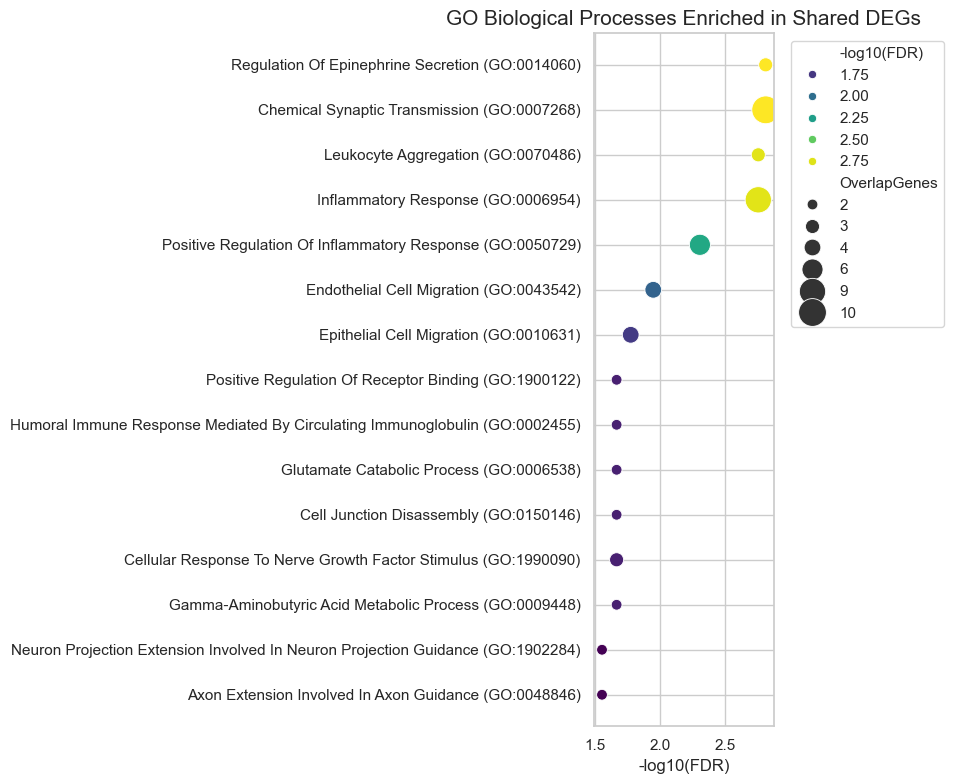

In [31]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=go_plot,
    x="-log10(FDR)",
    y="Term",
    size="OverlapGenes",
    hue="-log10(FDR)",
    palette="viridis",
    sizes=(60,400)
)

plt.title(
    "GO Biological Processes Enriched in Shared DEGs",
    fontsize=15
)

plt.xlabel("-log10(FDR)")
plt.ylabel("")

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "Results/Integrated/Figure5_GO_Shared.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
go_results.to_csv(
    "Results/Integrated/GO_Shared_DEGs.csv",
    index=False
)

In [33]:
kegg = gp.enrichr(
    gene_list=shared_genes,
    gene_sets="KEGG_2021_Human",
    organism="human",
    outdir=None
)

kegg_results = kegg.results.copy()

kegg_results = kegg_results.sort_values(
    "Adjusted P-value"
)

kegg_results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Complement and coagulation cascades,6/85,0.000009,0.000661,0,0,14.059860,163.896474,C4B;C1QB;C4A;F13A1;VSIG4;C1QC
1,KEGG_2021_Human,GABAergic synapse,6/89,0.000011,0.000661,0,0,13.379574,152.408866,GABRA1;GNG2;SLC32A1;GAD1;GAD2;GABRG2
2,KEGG_2021_Human,Neuroactive ligand-receptor interaction,9/341,0.000138,0.005385,0,0,5.097168,45.301970,ADCYAP1;GABRA1;SST;NMU;CRH;TAC3;TAC1;VIP;GABRG2
3,KEGG_2021_Human,Pertussis,4/76,0.000906,0.026510,0,0,10.099388,70.757569,C4B;C1QB;C4A;C1QC
4,KEGG_2021_Human,Nicotine addiction,3/40,0.001490,0.026933,0,0,14.631450,95.235400,GABRA1;SLC32A1;GABRG2


In [34]:
kegg_plot = kegg_results.head(15).copy()

kegg_plot["OverlapGenes"] = (
    kegg_plot["Overlap"]
    .str.split("/")
    .apply(lambda x: int(x[0]))
)

kegg_plot["-log10(FDR)"] = -np.log10(
    kegg_plot["Adjusted P-value"]
)

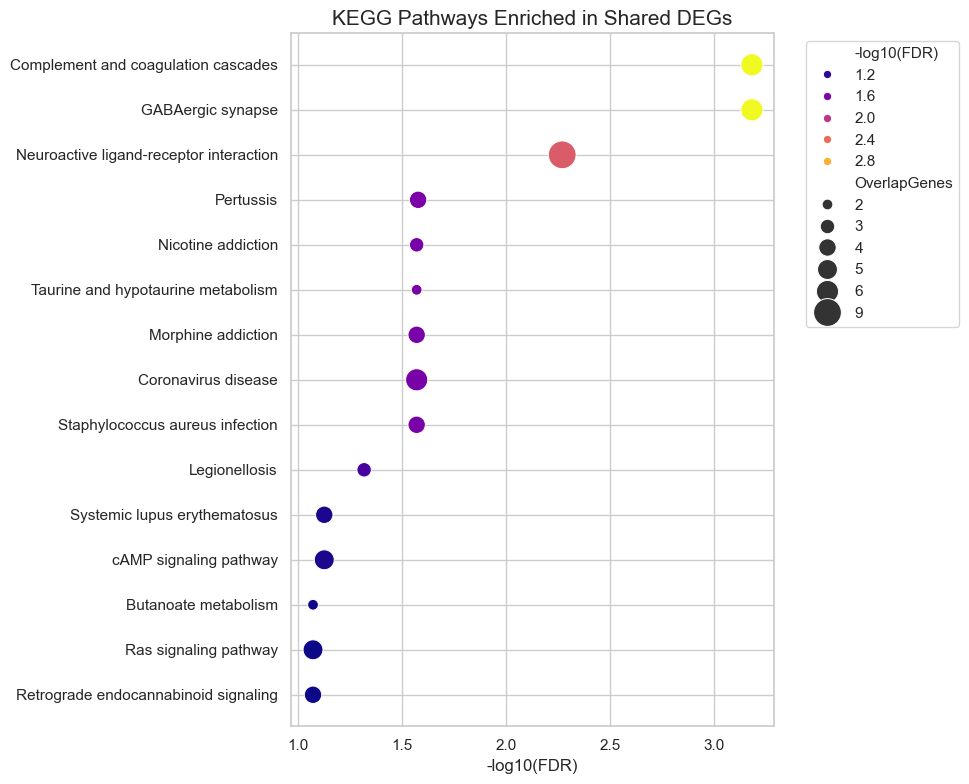

In [35]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=kegg_plot,
    x="-log10(FDR)",
    y="Term",
    size="OverlapGenes",
    hue="-log10(FDR)",
    palette="plasma",
    sizes=(60,400)
)

plt.title(
    "KEGG Pathways Enriched in Shared DEGs",
    fontsize=15
)

plt.xlabel("-log10(FDR)")
plt.ylabel("")

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "Results/Integrated/Figure6_KEGG_Shared.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
kegg_results.to_csv(
    "Results/Integrated/KEGG_Shared_DEGs.csv",
    index=False
)

In [37]:
import os

os.makedirs("Results/Integrated", exist_ok=True)

with open("Results/Integrated/shared_genes.txt", "w") as f:
    for gene in shared_genes:
        f.write(gene + "\n")

print(f"{len(shared_genes)} genes exported.")

113 genes exported.


In [38]:
import requests
import pandas as pd

string_api_url = "https://string-db.org/api"

output_format = "tsv-no-header"
method = "network"

params = {

    "identifiers": "%0d".join(shared_genes),

    "species": 9606,

    "required_score": 700,

    "caller_identity": "Alzheimer_Project"

}

request_url = "/".join([
    string_api_url,
    output_format,
    method
])

response = requests.post(request_url, data=params)

lines = response.text.strip().split("\n")

network = []

for line in lines:

    l = line.split("\t")

    network.append([

        l[2],      # protein1

        l[3],      # protein2

        float(l[5])

    ])

network_df = pd.DataFrame(
    network,
    columns=["Protein1", "Protein2", "Score"]
)

network_df.head()

,Protein1,Protein2,Score
0,PVALB,BDNF,0.776
1,PVALB,VIP,0.790
2,PVALB,SLC32A1,0.812
3,PVALB,GAD2,0.835
4,PVALB,SST,0.937


In [39]:
network_df.to_csv(
    "Results/Integrated/STRING_network.csv",
    index=False
)

print(network_df.shape)

(75, 3)


In [40]:
print("Edges:", len(network_df))

proteins = set(network_df["Protein1"]) | set(network_df["Protein2"])

print("Nodes:", len(proteins))

Edges: 75
Nodes: 47


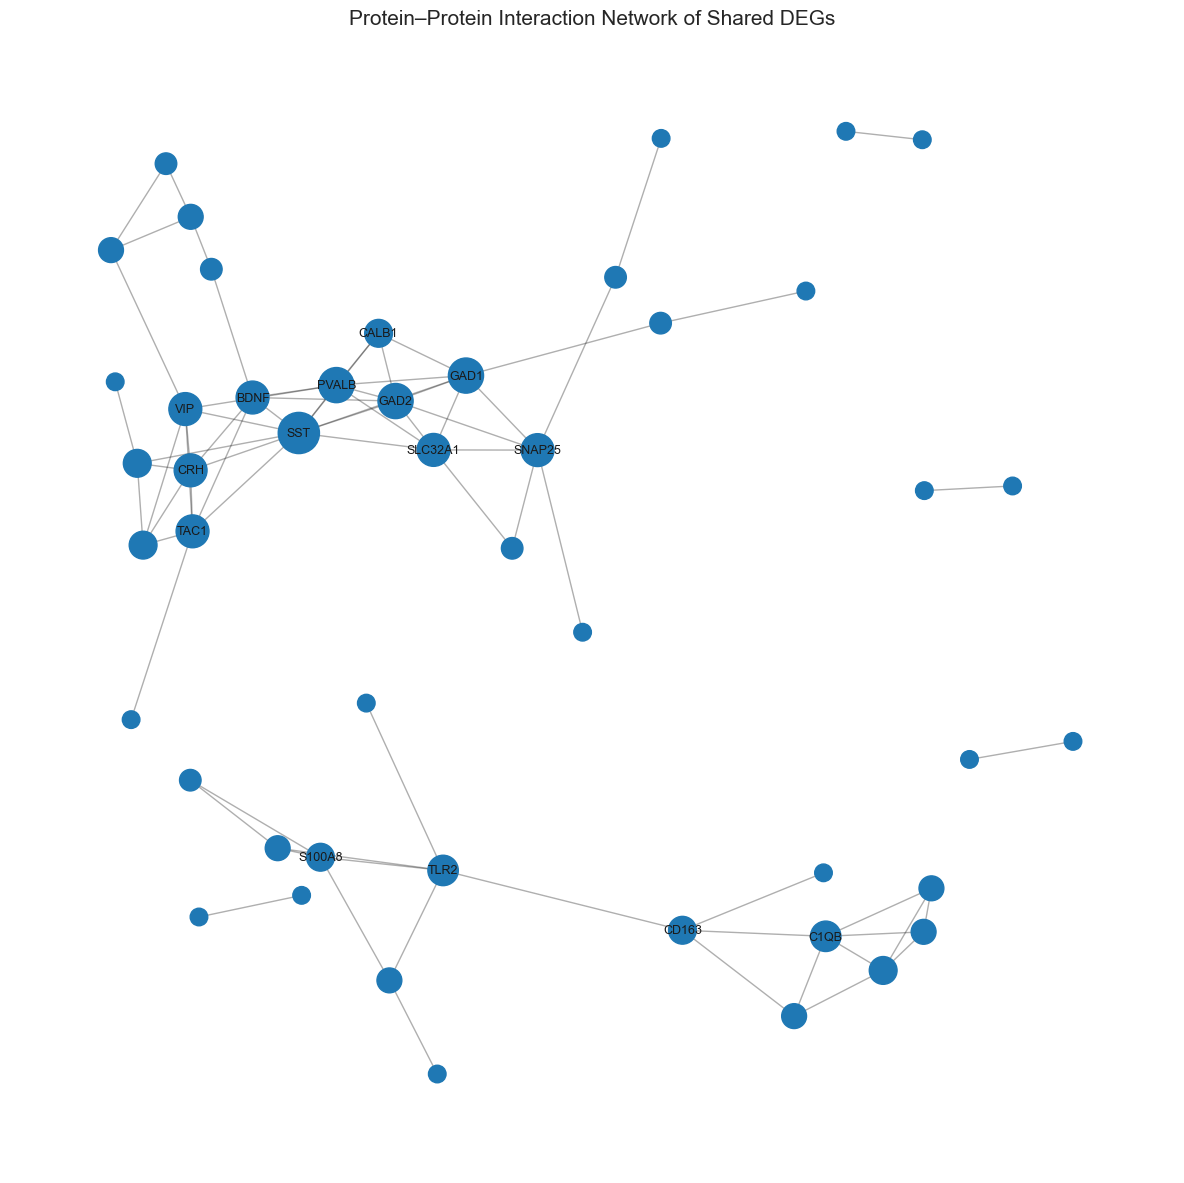

In [43]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.from_pandas_edgelist(
    network_df,
    "Protein1",
    "Protein2"
)

degree = dict(G.degree())

node_sizes = [
    degree[node] * 80 + 80
    for node in G.nodes()
]

plt.figure(figsize=(12,12))

pos = nx.spring_layout(
    G,
    k=0.35,
    seed=42
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.35,
    width=1
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
)

# Label only the 15 most connected proteins
top_nodes = sorted(
    degree,
    key=degree.get,
    reverse=True
)[:15]

nx.draw_networkx_labels(
    G,
    pos,
    labels={n:n for n in top_nodes},
    font_size=9
)

plt.title(
    "Protein–Protein Interaction Network of Shared DEGs",
    fontsize=15
)

plt.axis("off")

plt.tight_layout()

plt.savefig(
    "Results/Integrated/Figure7_STRING_network.png",
    dpi=300
)

plt.show()

In [44]:
degree = nx.degree_centrality(G)

hub = (
    pd.DataFrame.from_dict(
        degree,
        orient="index",
        columns=["DegreeCentrality"]
    )
    .sort_values(
        "DegreeCentrality",
        ascending=False
    )
)

hub.head(20)

,DegreeCentrality
SST,0.217391
PVALB,0.152174
GAD2,0.152174
GAD1,0.152174
VIP,0.130435
SLC32A1,0.130435
SNAP25,0.130435
TAC1,0.130435
CRH,0.130435
BDNF,0.130435


In [45]:
hub.to_csv(
    "Results/Integrated/Hub_Genes.csv"
)

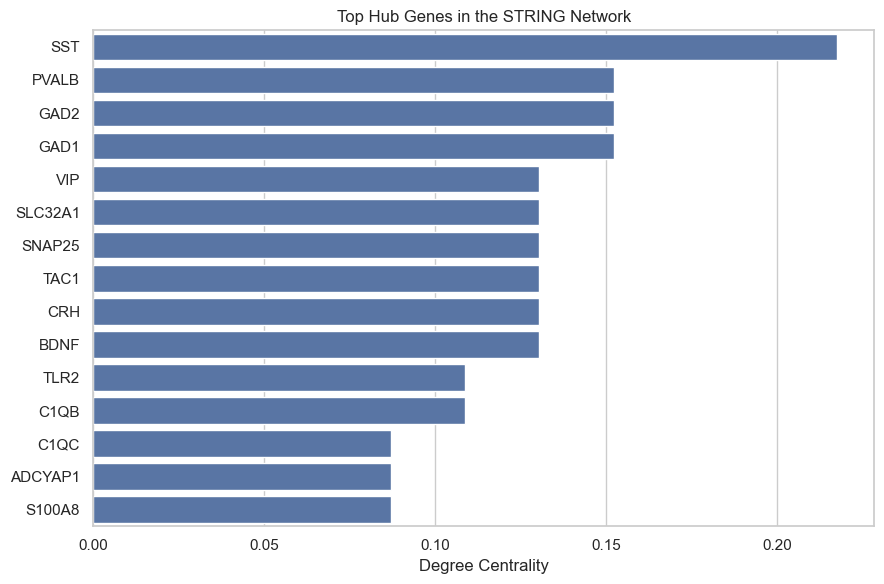

In [46]:
plt.figure(figsize=(9,6))

hub_top = hub.head(15)

sns.barplot(
    data=hub_top,
    x="DegreeCentrality",
    y=hub_top.index
)

plt.title(
    "Top Hub Genes in the STRING Network"
)

plt.xlabel("Degree Centrality")
plt.ylabel("")

plt.tight_layout()

plt.savefig(
    "Results/Integrated/Figure8_HubGenes.png",
    dpi=300
)

plt.show()

In [53]:
shared_df = pd.DataFrame({"Gene": shared})

shared_df.to_csv(
    "Results/Integrated/Shared_DEGs.csv",
    index=False
)

print("Shared gene list saved.")

Shared gene list saved.
